In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from scipy.fft import rfft, rfftfreq
from scipy.stats import kurtosis

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
PROJECT_ROOT = Path(
    r"C:\Users\armaa\OneDrive\Desktop\TinyML-Vibration-Anomaly-Detection"
)

print("Project root:")
print(PROJECT_ROOT)

Project root:
C:\Users\armaa\OneDrive\Desktop\TinyML-Vibration-Anomaly-Detection


In [3]:
WINDOW_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "CWRU"
    / "windows"
)

print("Window directory:")
print(WINDOW_DIR)

print("\nDirectory exists:", WINDOW_DIR.exists())

Window directory:
C:\Users\armaa\OneDrive\Desktop\TinyML-Vibration-Anomaly-Detection\data\processed\CWRU\windows

Directory exists: True


In [4]:
FS = 12000
WINDOW_SIZE = 12000
OVERLAP = 0.50

CLASS_NAMES = [
    "Healthy",
    "Ball",
    "Inner Race",
    "Outer Race"
]

CLASS_TO_INDEX = {
    name: index
    for index, name in enumerate(CLASS_NAMES)
}

print("Sampling frequency:", FS, "Hz")
print("Window size:", WINDOW_SIZE, "samples")
print("Window duration:", WINDOW_SIZE / FS, "second")
print("Overlap:", OVERLAP * 100, "%")

print("\nClasses:")
for index, name in enumerate(CLASS_NAMES):
    print(index, "=", name)

Sampling frequency: 12000 Hz
Window size: 12000 samples
Window duration: 1.0 second
Overlap: 50.0 %

Classes:
0 = Healthy
1 = Ball
2 = Inner Race
3 = Outer Race


In [5]:
TRAIN_METADATA = WINDOW_DIR / "train_metadata.csv"
VAL_METADATA = WINDOW_DIR / "validation_metadata.csv"
TEST_METADATA = WINDOW_DIR / "test_metadata.csv"

train_df = pd.read_csv(TRAIN_METADATA)
val_df = pd.read_csv(VAL_METADATA)
test_df = pd.read_csv(TEST_METADATA)

print("Train metadata shape:", train_df.shape)
print("Validation metadata shape:", val_df.shape)
print("Test metadata shape:", test_df.shape)

Train metadata shape: (390, 7)
Validation metadata shape: (117, 7)
Test metadata shape: (76, 7)


In [6]:
print("Metadata columns:")
print(train_df.columns.tolist())

Metadata columns:
['recording_id', 'source_file', 'signal_id', 'class', 'window_id', 'start_sample', 'end_sample']


In [7]:
display(train_df.head())

,recording_id,source_file,signal_id,class,window_id,start_sample,end_sample
0,B007_3_X121,B007_3.mat,X121,Ball,0,0,12000
1,B007_3_X121,B007_3.mat,X121,Ball,1,6000,18000
2,B007_3_X121,B007_3.mat,X121,Ball,2,12000,24000
3,B007_3_X121,B007_3.mat,X121,Ball,3,18000,30000
4,B007_3_X121,B007_3.mat,X121,Ball,4,24000,36000


In [8]:
print("Train windows:", len(train_df))
print("Validation windows:", len(val_df))
print("Test windows:", len(test_df))

total_windows = (
    len(train_df)
    + len(val_df)
    + len(test_df)
)

print("\nTotal windows:", total_windows)

Train windows: 390
Validation windows: 117
Test windows: 76

Total windows: 583


In [9]:
train_recordings = set(train_df["recording_id"])
val_recordings = set(val_df["recording_id"])
test_recordings = set(test_df["recording_id"])

print("Train ∩ Validation:",
      train_recordings.intersection(val_recordings))

print("Train ∩ Test:",
      train_recordings.intersection(test_recordings))

print("Validation ∩ Test:",
      val_recordings.intersection(test_recordings))

Train ∩ Validation: set()
Train ∩ Test: set()
Validation ∩ Test: set()


In [10]:
train_df["label"] = train_df["class"].map(CLASS_TO_INDEX)
val_df["label"] = val_df["class"].map(CLASS_TO_INDEX)
test_df["label"] = test_df["class"].map(CLASS_TO_INDEX)

print("Label mapping:")
print(CLASS_TO_INDEX)

Label mapping:
{'Healthy': 0, 'Ball': 1, 'Inner Race': 2, 'Outer Race': 3}


In [11]:
print("Unique train labels:",
      sorted(train_df["label"].unique()))

print("Unique validation labels:",
      sorted(val_df["label"].unique()))

print("Unique test labels:",
      sorted(test_df["label"].unique()))

Unique train labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Unique validation labels: [np.int64(0), np.int64(1), np.int64(3)]
Unique test labels: [np.int64(1), np.int64(2), np.int64(3)]


In [12]:
def get_window_path(row, split):
    recording_id = str(row["recording_id"])
    window_id = int(row["window_id"])

    filename = (
        f"{recording_id}_window_{window_id:04d}.npy"
    )

    return WINDOW_DIR / split / filename

In [13]:
example_row = train_df.iloc[0]

example_path = get_window_path(
    example_row,
    "train"
)

print("Example window path:")
print(example_path)

print("\nFile exists:", example_path.exists())

Example window path:
C:\Users\armaa\OneDrive\Desktop\TinyML-Vibration-Anomaly-Detection\data\processed\CWRU\windows\train\B007_3_X121_window_0000.npy

File exists: True


In [14]:
example_signal = np.load(example_path)

print("Signal shape:", example_signal.shape)
print("Signal dtype:", example_signal.dtype)
print("Number of samples:", len(example_signal))

Signal shape: (12000,)
Signal dtype: float64
Number of samples: 12000


In [15]:
assert example_signal.shape == (12000,)

print("Window size verification passed.")

Window size verification passed.


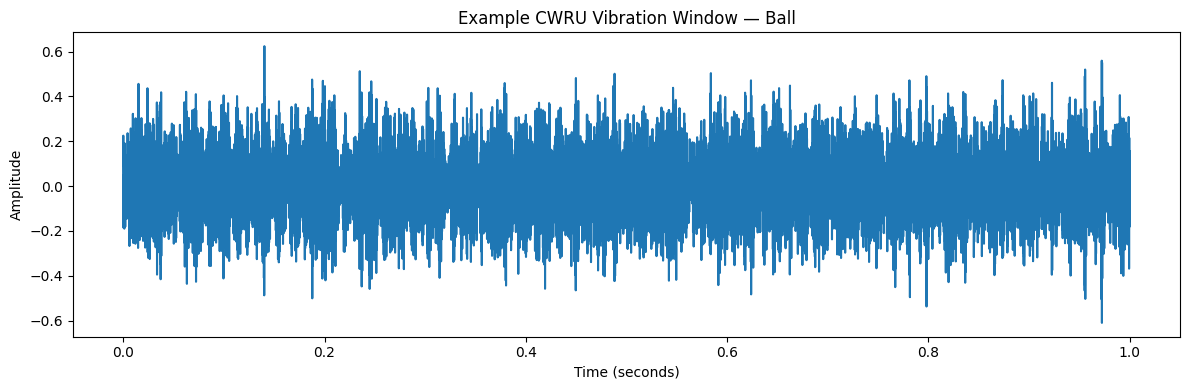

In [16]:
time = np.arange(WINDOW_SIZE) / FS

plt.figure(figsize=(12, 4))

plt.plot(time, example_signal)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title(
    f"Example CWRU Vibration Window — "
    f"{example_row['class']}"
)

plt.tight_layout()
plt.show()

In [17]:
def extract_window_features(signal, fs=12000):

    signal = np.asarray(signal, dtype=np.float64)

    if signal.shape != (WINDOW_SIZE,):
        raise ValueError(
            f"Expected signal shape "
            f"({WINDOW_SIZE},), "
            f"got {signal.shape}"
        )

    # Remove DC component
    x = signal - np.mean(signal)

    # ============================================
    # TIME-DOMAIN FEATURES
    # ============================================

    rms = np.sqrt(
        np.mean(x ** 2)
    )

    variance = np.var(x)

    std = np.std(x)

    kurt = kurtosis(
        x,
        fisher=False,
        bias=False
    )

    peak = np.max(
        np.abs(x)
    )

    crest_factor = (
        peak / (rms + 1e-12)
    )

    peak_to_peak = (
        np.max(x) - np.min(x)
    )

    maximum = np.max(x)

    minimum = np.min(x)

    # ============================================
    # FFT
    # ============================================

    fft_values = np.abs(
        rfft(x)
    )

    frequencies = rfftfreq(
        len(x),
        d=1 / fs
    )

    # Remove DC from dominant-frequency search
    fft_values_no_dc = fft_values.copy()
    fft_values_no_dc[0] = 0

    # ============================================
    # FREQUENCY-DOMAIN FEATURES
    # ============================================

    dominant_index = np.argmax(
        fft_values_no_dc
    )

    dominant_frequency = (
        frequencies[dominant_index]
    )

    spectral_centroid = (
        np.sum(
            frequencies * fft_values
        )
        /
        (np.sum(fft_values) + 1e-12)
    )

    spectral_rms = np.sqrt(
        np.mean(
            fft_values ** 2
        )
    )

    total_spectral_energy = np.sum(
        fft_values ** 2
    )

    # ============================================
    # FREQUENCY BANDS
    # ============================================

    low_band = (
        (frequencies >= 0)
        &
        (frequencies < 1000)
    )

    mid_band = (
        (frequencies >= 1000)
        &
        (frequencies < 3000)
    )

    high_band = (
        (frequencies >= 3000)
        &
        (frequencies <= fs / 2)
    )

    low_frequency_energy = np.sum(
        fft_values[low_band] ** 2
    )

    mid_frequency_energy = np.sum(
        fft_values[mid_band] ** 2
    )

    high_frequency_energy = np.sum(
        fft_values[high_band] ** 2
    )

    # ============================================
    # RETURN
    # ============================================

    return {
        "RMS": rms,
        "Variance": variance,
        "Std": std,
        "Kurtosis": kurt,
        "Crest_Factor": crest_factor,
        "Peak_to_Peak": peak_to_peak,
        "Maximum": maximum,
        "Minimum": minimum,
        "Dominant_Frequency": dominant_frequency,
        "Spectral_Centroid": spectral_centroid,
        "Spectral_RMS": spectral_rms,
        "Total_Spectral_Energy": total_spectral_energy,
        "Low_Frequency_Energy": low_frequency_energy,
        "Mid_Frequency_Energy": mid_frequency_energy,
        "High_Frequency_Energy": high_frequency_energy
    }

In [18]:
example_features = extract_window_features(
    example_signal,
    fs=FS
)

print("Extracted features:\n")

for feature, value in example_features.items():
    print(
        f"{feature:30s}: {value:.6f}"
    )

Extracted features:

RMS                           : 0.154767
Variance                      : 0.023953
Std                           : 0.154767
Kurtosis                      : 2.833428
Crest_Factor                  : 4.009166
Peak_to_Peak                  : 1.233532
Maximum                       : 0.620485
Minimum                       : -0.613047
Dominant_Frequency            : 3380.000000
Spectral_Centroid             : 2693.925741
Spectral_RMS                  : 16.952422
Total_Spectral_Energy         : 1724594.964661
Low_Frequency_Energy          : 77840.866602
Mid_Frequency_Energy          : 383991.098023
High_Frequency_Energy         : 1262763.000035


In [19]:
def build_feature_dataframe(metadata_df, split):

    records = []

    for index, row in metadata_df.iterrows():

        window_path = get_window_path(
            row,
            split
        )

        if not window_path.exists():
            raise FileNotFoundError(
                f"Window file not found:\n"
                f"{window_path}"
            )

        signal = np.load(
            window_path
        )

        features = extract_window_features(
            signal,
            fs=FS
        )

        record = {
            "recording_id": row["recording_id"],
            "source_file": row["source_file"],
            "signal_id": row["signal_id"],
            "class": row["class"],
            "label": row["label"],
            "window_id": row["window_id"],
            "start_sample": row["start_sample"],
            "end_sample": row["end_sample"]
        }

        record.update(features)

        records.append(record)

    return pd.DataFrame(records)

In [20]:
print("Extracting training features...")

train_features_df = build_feature_dataframe(
    train_df,
    "train"
)

print(
    "Training feature extraction complete."
)

print(
    "Shape:",
    train_features_df.shape
)

Extracting training features...
Training feature extraction complete.
Shape: (390, 23)


In [21]:
print("Extracting validation features...")

val_features_df = build_feature_dataframe(
    val_df,
    "validation"
)

print(
    "Validation feature extraction complete."
)

print(
    "Shape:",
    val_features_df.shape
)

Extracting validation features...
Validation feature extraction complete.
Shape: (117, 23)


In [22]:
print("Extracting test features...")

test_features_df = build_feature_dataframe(
    test_df,
    "test"
)

print(
    "Test feature extraction complete."
)

print(
    "Shape:",
    test_features_df.shape
)

Extracting test features...
Test feature extraction complete.
Shape: (76, 23)


In [23]:
print("================================")
print("BASELINE FEATURE DATASET")
print("================================")

print("Train:", train_features_df.shape)
print("Validation:", val_features_df.shape)
print("Test:", test_features_df.shape)

print("\nTotal samples:")

print(
    len(train_features_df)
    +
    len(val_features_df)
    +
    len(test_features_df)
)

BASELINE FEATURE DATASET
Train: (390, 23)
Validation: (117, 23)
Test: (76, 23)

Total samples:
583


In [25]:
print("Training NaN count:")
print(
    train_features_df.isna().sum()
)

print("\nValidation NaN count:")
print(
    val_features_df.isna().sum()
)

print("\nTest NaN count:")
print(
    test_features_df.isna().sum()
)

Training NaN count:
recording_id             0
source_file              0
signal_id                0
class                    0
label                    0
window_id                0
start_sample             0
end_sample               0
RMS                      0
Variance                 0
Std                      0
Kurtosis                 0
Crest_Factor             0
Peak_to_Peak             0
Maximum                  0
Minimum                  0
Dominant_Frequency       0
Spectral_Centroid        0
Spectral_RMS             0
Total_Spectral_Energy    0
Low_Frequency_Energy     0
Mid_Frequency_Energy     0
High_Frequency_Energy    0
dtype: int64

Validation NaN count:
recording_id             0
source_file              0
signal_id                0
class                    0
label                    0
window_id                0
start_sample             0
end_sample               0
RMS                      0
Variance                 0
Std                      0
Kurtosis                 0

In [26]:
numeric_train = train_features_df.select_dtypes(
    include=[np.number]
)

numeric_val = val_features_df.select_dtypes(
    include=[np.number]
)

numeric_test = test_features_df.select_dtypes(
    include=[np.number]
)

print(
    "Train infinite values:",
    np.isinf(numeric_train).sum().sum()
)

print(
    "Validation infinite values:",
    np.isinf(numeric_val).sum().sum()
)

print(
    "Test infinite values:",
    np.isinf(numeric_test).sum().sum()
)

Train infinite values: 0
Validation infinite values: 0
Test infinite values: 0


In [27]:
FEATURE_COLUMNS = [
    "RMS",
    "Variance",
    "Std",
    "Kurtosis",
    "Crest_Factor",
    "Peak_to_Peak",
    "Maximum",
    "Minimum",
    "Dominant_Frequency",
    "Spectral_Centroid",
    "Spectral_RMS",
    "Total_Spectral_Energy",
    "Low_Frequency_Energy",
    "Mid_Frequency_Energy",
    "High_Frequency_Energy"
]

print("Number of baseline features:")
print(len(FEATURE_COLUMNS))

print("\nFeatures:")
for i, feature in enumerate(FEATURE_COLUMNS, start=1):
    print(f"{i}. {feature}")

Number of baseline features:
15

Features:
1. RMS
2. Variance
3. Std
4. Kurtosis
5. Crest_Factor
6. Peak_to_Peak
7. Maximum
8. Minimum
9. Dominant_Frequency
10. Spectral_Centroid
11. Spectral_RMS
12. Total_Spectral_Energy
13. Low_Frequency_Energy
14. Mid_Frequency_Energy
15. High_Frequency_Energy


In [29]:
X_train = train_features_df[
    FEATURE_COLUMNS
]

y_train = train_features_df[
    "label"
]

X_val = val_features_df[
    FEATURE_COLUMNS
]

y_val = val_features_df[
    "label"
]

X_test = test_features_df[
    FEATURE_COLUMNS
]

y_test = test_features_df[
    "label"
]
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nX_val:", X_val.shape)
print("y_val:", y_val.shape)

print("\nX_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (390, 15)
y_train: (390,)

X_val: (117, 15)
y_val: (117,)

X_test: (76, 15)
y_test: (76,)


In [30]:
BASELINE_FEATURE_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "CWRU"
    / "baseline_features"
)

BASELINE_FEATURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

train_features_df.to_csv(
    BASELINE_FEATURE_DIR
    / "train_features.csv",
    index=False
)

val_features_df.to_csv(
    BASELINE_FEATURE_DIR
    / "validation_features.csv",
    index=False
)

test_features_df.to_csv(
    BASELINE_FEATURE_DIR
    / "test_features.csv",
    index=False
)

print("Baseline feature files saved.")
print(BASELINE_FEATURE_DIR)

Baseline feature files saved.
C:\Users\armaa\OneDrive\Desktop\TinyML-Vibration-Anomaly-Detection\data\processed\CWRU\baseline_features


In [31]:
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

print("Random Forest libraries imported.")

Random Forest libraries imported.


In [32]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest training completed.")

Random Forest training completed.


In [39]:
y_val_pred_rf = rf_model.predict(X_val)

rf_val_accuracy = accuracy_score(
    y_val,
    y_val_pred_rf
)

print(
    f"Random Forest Validation Accuracy: "
    f"{rf_val_accuracy:.4f}"
)


Random Forest Validation Accuracy: 1.0000


In [41]:

print(type(y_val))
print(type(y_val_pred_rf))

print("y_val shape:", y_val.shape)
print("y_val_pred_rf shape:", y_val_pred_rf.shape)

<class 'pandas.core.series.Series'>
<class 'numpy.ndarray'>
y_val shape: (117,)
y_val_pred_rf shape: (117,)


In [43]:
report = classification_report(
    y_val,
    y_val_pred_rf,
    target_names=CLASS_NAMES,
    zero_division=0
)

print(report)

ValueError: Number of classes, 3, does not match size of target_names, 4. Try specifying the labels parameter

In [44]:
print("CLASS_NAMES =", CLASS_NAMES)
print("y_val type =", type(y_val))
print("y_val_pred_rf type =", type(y_val_pred_rf))
print("Shapes:", y_val.shape, y_val_pred_rf.shape)

CLASS_NAMES = ['Healthy', 'Ball', 'Inner Race', 'Outer Race']
y_val type = <class 'pandas.core.series.Series'>
y_val_pred_rf type = <class 'numpy.ndarray'>
Shapes: (117,) (117,)


In [45]:
from sklearn.metrics import classification_report

report = classification_report(
    y_val,
    y_val_pred_rf,
    target_names=CLASS_NAMES,
    zero_division=0
)

print(report)

ValueError: Number of classes, 3, does not match size of target_names, 4. Try specifying the labels parameter

In [46]:
print("Before report")

report = classification_report(
    y_val,
    y_val_pred_rf,
    target_names=CLASS_NAMES,
    zero_division=0
)

print("After report")
print(report)

Before report


ValueError: Number of classes, 3, does not match size of target_names, 4. Try specifying the labels parameter

In [47]:
print("Validation true labels:")
print(sorted(y_val.unique()))

print("\nValidation true class counts:")
print(train_features_df["class"].value_counts())

print("\nValidation class counts:")
print(val_features_df["class"].value_counts())

print("\nValidation predicted labels:")
print(sorted(np.unique(y_val_pred_rf)))

Validation true labels:
[np.int64(0), np.int64(1), np.int64(3)]

Validation true class counts:
class
Healthy       276
Inner Race     57
Outer Race     38
Ball           19
Name: count, dtype: int64

Validation class counts:
class
Healthy       79
Ball          19
Outer Race    19
Name: count, dtype: int64

Validation predicted labels:
[np.int64(0), np.int64(1), np.int64(3)]


In [48]:
from sklearn.metrics import classification_report

rf_val_report = classification_report(
    y_val,
    y_val_pred_rf,
    labels=[0, 1, 2, 3],
    target_names=CLASS_NAMES,
    zero_division=0
)

print(rf_val_report)

              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00        79
        Ball       1.00      1.00      1.00        19
  Inner Race       0.00      0.00      0.00         0
  Outer Race       1.00      1.00      1.00        19

    accuracy                           1.00       117
   macro avg       0.75      0.75      0.75       117
weighted avg       1.00      1.00      1.00       117



In [49]:
print("Validation true labels:")
print(sorted(y_val.unique()))

print("\nValidation class counts:")
print(val_features_df["class"].value_counts())

print("\nValidation predicted labels:")
print(sorted(np.unique(y_val_pred_rf)))

Validation true labels:
[np.int64(0), np.int64(1), np.int64(3)]

Validation class counts:
class
Healthy       79
Ball          19
Outer Race    19
Name: count, dtype: int64

Validation predicted labels:
[np.int64(0), np.int64(1), np.int64(3)]


In [51]:
print("TRAIN RECORDINGS")
print(
    train_df[
        ["recording_id", "class"]
    ].drop_duplicates().sort_values("class")
)

print("\nVALIDATION RECORDINGS")
print(
    val_df[
        ["recording_id", "class"]
    ].drop_duplicates().sort_values("class")
)

print("\nTEST RECORDINGS")
print(
    test_df[
        ["recording_id", "class"]
    ].drop_duplicates().sort_values("class")
)
print("Number of unique recordings")

print(
    "Train:",
    train_df["recording_id"].nunique()
)

print(
    "Validation:",
    val_df["recording_id"].nunique()
)

print(
    "Test:",
    test_df["recording_id"].nunique()
)

TRAIN RECORDINGS
       recording_id       class
0       B007_3_X121        Ball
76    NORMAL_0_X097     Healthy
115   NORMAL_1_X098     Healthy
194   NORMAL_2_X098     Healthy
273   NORMAL_2_X099     Healthy
19     IR007_0_X105  Inner Race
38     IR007_2_X107  Inner Race
57     IR007_3_X108  Inner Race
352  OR007@6_0_X130  Outer Race
371  OR007@6_3_X133  Outer Race

VALIDATION RECORDINGS
      recording_id       class
0      B007_2_X120        Ball
19   NORMAL_3_X100     Healthy
98  OR007@6_1_X131  Outer Race

TEST RECORDINGS
      recording_id       class
0      B007_0_X118        Ball
19     B007_1_X119        Ball
38    IR007_1_X106  Inner Race
57  OR007@6_2_X132  Outer Race
Number of unique recordings
Train: 10
Validation: 3
Test: 4


In [52]:
print("TRAIN")
print(train_df["class"].value_counts())

print("\nVALIDATION")
print(val_df["class"].value_counts())

print("\nTEST")
print(test_df["class"].value_counts())

TRAIN
class
Healthy       276
Inner Race     57
Outer Race     38
Ball           19
Name: count, dtype: int64

VALIDATION
class
Healthy       79
Ball          19
Outer Race    19
Name: count, dtype: int64

TEST
class
Ball          38
Inner Race    19
Outer Race    19
Name: count, dtype: int64


In [53]:
print("========== TRAIN RECORDINGS ==========")

display(
    train_df[
        ["recording_id", "source_file", "signal_id", "class"]
    ].drop_duplicates()
    .sort_values(["class", "recording_id"])
)

print("\n========== VALIDATION RECORDINGS ==========")

display(
    val_df[
        ["recording_id", "source_file", "signal_id", "class"]
    ].drop_duplicates()
    .sort_values(["class", "recording_id"])
)

print("\n========== TEST RECORDINGS ==========")

display(
    test_df[
        ["recording_id", "source_file", "signal_id", "class"]
    ].drop_duplicates()
    .sort_values(["class", "recording_id"])
)

========== TRAIN RECORDINGS ==========


,recording_id,source_file,signal_id,class
0,B007_3_X121,B007_3.mat,X121,Ball
76,NORMAL_0_X097,NORMAL_0.mat,X097,Healthy
115,NORMAL_1_X098,NORMAL_1.mat,X098,Healthy
194,NORMAL_2_X098,NORMAL_2.mat,X098,Healthy
273,NORMAL_2_X099,NORMAL_2.mat,X099,Healthy
19,IR007_0_X105,IR007_0.mat,X105,Inner Race
38,IR007_2_X107,IR007_2.mat,X107,Inner Race
57,IR007_3_X108,IR007_3.mat,X108,Inner Race
352,OR007@6_0_X130,OR007@6_0.mat,X130,Outer Race
371,OR007@6_3_X133,OR007@6_3.mat,X133,Outer Race



========== VALIDATION RECORDINGS ==========


,recording_id,source_file,signal_id,class
0,B007_2_X120,B007_2.mat,X120,Ball
19,NORMAL_3_X100,NORMAL_3.mat,X100,Healthy
98,OR007@6_1_X131,OR007@6_1.mat,X131,Outer Race



========== TEST RECORDINGS ==========


,recording_id,source_file,signal_id,class
0,B007_0_X118,B007_0.mat,X118,Ball
19,B007_1_X119,B007_1.mat,X119,Ball
38,IR007_1_X106,IR007_1.mat,X106,Inner Race
57,OR007@6_2_X132,OR007@6_2.mat,X132,Outer Race


In [54]:
print("Unique recordings:")
print("Train:", train_df["recording_id"].nunique())
print("Validation:", val_df["recording_id"].nunique())
print("Test:", test_df["recording_id"].nunique())

print("\nTotal unique recordings:")
print(
    len(
        set(train_df["recording_id"])
        | set(val_df["recording_id"])
        | set(test_df["recording_id"])
    )
)

Unique recordings:
Train: 10
Validation: 3
Test: 4

Total unique recordings:
17


In [55]:
all_metadata = pd.concat(
    [
        train_df,
        val_df,
        test_df
    ],
    ignore_index=True
)

recording_table = (
    all_metadata[
        [
            "recording_id",
            "source_file",
            "signal_id",
            "class"
        ]
    ]
    .drop_duplicates(
        subset=["recording_id"]
    )
    .sort_values(
        ["class", "recording_id"]
    )
    .reset_index(drop=True)
)

print(
    "Unique recordings:",
    len(recording_table)
)

display(recording_table)

Unique recordings: 17


,recording_id,source_file,signal_id,class
0,B007_0_X118,B007_0.mat,X118,Ball
1,B007_1_X119,B007_1.mat,X119,Ball
2,B007_2_X120,B007_2.mat,X120,Ball
3,B007_3_X121,B007_3.mat,X121,Ball
4,NORMAL_0_X097,NORMAL_0.mat,X097,Healthy
5,NORMAL_1_X098,NORMAL_1.mat,X098,Healthy
6,NORMAL_2_X098,NORMAL_2.mat,X098,Healthy
7,NORMAL_2_X099,NORMAL_2.mat,X099,Healthy
8,NORMAL_3_X100,NORMAL_3.mat,X100,Healthy
9,IR007_0_X105,IR007_0.mat,X105,Inner Race


In [57]:
signal_groups = (
    all_metadata[
        [
            "signal_id",
            "source_file",
            "class"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        ["class", "signal_id"]
    )
    .reset_index(drop=True)
)

print(
    "Unique signal groups:",
    signal_groups["signal_id"].nunique()
)

display(signal_groups)

Unique signal groups: 16


,signal_id,source_file,class
0,X118,B007_0.mat,Ball
1,X119,B007_1.mat,Ball
2,X120,B007_2.mat,Ball
3,X121,B007_3.mat,Ball
4,X097,NORMAL_0.mat,Healthy
5,X098,NORMAL_1.mat,Healthy
6,X098,NORMAL_2.mat,Healthy
7,X099,NORMAL_2.mat,Healthy
8,X100,NORMAL_3.mat,Healthy
9,X105,IR007_0.mat,Inner Race


In [56]:
print(
    recording_table.groupby("class")["recording_id"]
    .count()
)

class
Ball          4
Healthy       5
Inner Race    4
Outer Race    4
Name: recording_id, dtype: int64


In [58]:
x098_rows = all_metadata[
    all_metadata["signal_id"] == "X098"
]

display(
    x098_rows[
        [
            "recording_id",
            "source_file",
            "signal_id",
            "class",
            "window_id"
        ]
    ].head(20)
)

,recording_id,source_file,signal_id,class,window_id
115,NORMAL_1_X098,NORMAL_1.mat,X098,Healthy,0
116,NORMAL_1_X098,NORMAL_1.mat,X098,Healthy,1
117,NORMAL_1_X098,NORMAL_1.mat,X098,Healthy,2
118,NORMAL_1_X098,NORMAL_1.mat,X098,Healthy,3
119,NORMAL_1_X098,NORMAL_1.mat,X098,Healthy,4
120,NORMAL_1_X098,NORMAL_1.mat,X098,Healthy,5
121,NORMAL_1_X098,NORMAL_1.mat,X098,Healthy,6
122,NORMAL_1_X098,NORMAL_1.mat,X098,Healthy,7
123,NORMAL_1_X098,NORMAL_1.mat,X098,Healthy,8
124,NORMAL_1_X098,NORMAL_1.mat,X098,Healthy,9


In [59]:
print(
    "X098 source files:",
    x098_rows["source_file"].unique()
)

print(
    "X098 recording IDs:",
    x098_rows["recording_id"].unique()
)

X098 source files: ['NORMAL_1.mat' 'NORMAL_2.mat']
X098 recording IDs: ['NORMAL_1_X098' 'NORMAL_2_X098']


In [60]:
signal_groups = (
    all_metadata[
        [
            "signal_id",
            "source_file",
            "class"
        ]
    ]
    .drop_duplicates(
        subset=["signal_id"]
    )
    .sort_values(
        ["class", "signal_id"]
    )
    .reset_index(drop=True)
)

print(
    "Number of unique signal groups:",
    len(signal_groups)
)

display(signal_groups)

Number of unique signal groups: 16


,signal_id,source_file,class
0,X118,B007_0.mat,Ball
1,X119,B007_1.mat,Ball
2,X120,B007_2.mat,Ball
3,X121,B007_3.mat,Ball
4,X097,NORMAL_0.mat,Healthy
5,X098,NORMAL_1.mat,Healthy
6,X099,NORMAL_2.mat,Healthy
7,X100,NORMAL_3.mat,Healthy
8,X105,IR007_0.mat,Inner Race
9,X106,IR007_1.mat,Inner Race


In [61]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

train_signal_groups = []
val_signal_groups = []
test_signal_groups = []

for class_name in CLASS_NAMES:

    class_groups = signal_groups[
        signal_groups["class"] == class_name
    ]["signal_id"].tolist()

    print(
        f"{class_name}:",
        class_groups
    )

    # 2 groups for train, 2 groups temporarily held out
    train_groups, remaining_groups = train_test_split(
        class_groups,
        test_size=2,
        random_state=RANDOM_STATE
    )

    # 1 validation, 1 test
    val_groups, test_groups = train_test_split(
        remaining_groups,
        test_size=1,
        random_state=RANDOM_STATE
    )

    train_signal_groups.extend(train_groups)
    val_signal_groups.extend(val_groups)
    test_signal_groups.extend(test_groups)

print("\nTRAIN signal groups:")
print(train_signal_groups)

print("\nVALIDATION signal groups:")
print(val_signal_groups)

print("\nTEST signal groups:")
print(test_signal_groups)

Healthy: ['X097', 'X098', 'X099', 'X100']
Ball: ['X118', 'X119', 'X120', 'X121']
Inner Race: ['X105', 'X106', 'X107', 'X108']
Outer Race: ['X130', 'X131', 'X132', 'X133']

TRAIN signal groups:
['X097', 'X099', 'X118', 'X120', 'X105', 'X107', 'X130', 'X132']

VALIDATION signal groups:
['X098', 'X119', 'X106', 'X131']

TEST signal groups:
['X100', 'X121', 'X108', 'X133']


In [62]:
print("TRAIN GROUPS")

display(
    signal_groups[
        signal_groups["signal_id"].isin(
            train_signal_groups
        )
    ].sort_values("class")
)

print("\nVALIDATION GROUPS")

display(
    signal_groups[
        signal_groups["signal_id"].isin(
            val_signal_groups
        )
    ].sort_values("class")
)

print("\nTEST GROUPS")

display(
    signal_groups[
        signal_groups["signal_id"].isin(
            test_signal_groups
        )
    ].sort_values("class")
)

TRAIN GROUPS


,signal_id,source_file,class
0,X118,B007_0.mat,Ball
2,X120,B007_2.mat,Ball
4,X097,NORMAL_0.mat,Healthy
6,X099,NORMAL_2.mat,Healthy
8,X105,IR007_0.mat,Inner Race
10,X107,IR007_2.mat,Inner Race
12,X130,OR007@6_0.mat,Outer Race
14,X132,OR007@6_2.mat,Outer Race



VALIDATION GROUPS


,signal_id,source_file,class
1,X119,B007_1.mat,Ball
5,X098,NORMAL_1.mat,Healthy
9,X106,IR007_1.mat,Inner Race
13,X131,OR007@6_1.mat,Outer Race



TEST GROUPS


,signal_id,source_file,class
3,X121,B007_3.mat,Ball
7,X100,NORMAL_3.mat,Healthy
11,X108,IR007_3.mat,Inner Race
15,X133,OR007@6_3.mat,Outer Race


In [63]:
for split_name, groups in [
    ("Train", train_signal_groups),
    ("Validation", val_signal_groups),
    ("Test", test_signal_groups)
]:

    print(
        f"\n{split_name}:"
    )

    print(
        signal_groups[
            signal_groups["signal_id"].isin(groups)
        ]["class"].value_counts()
    )


Train:
class
Ball          2
Healthy       2
Inner Race    2
Outer Race    2
Name: count, dtype: int64

Validation:
class
Ball          1
Healthy       1
Inner Race    1
Outer Race    1
Name: count, dtype: int64

Test:
class
Ball          1
Healthy       1
Inner Race    1
Outer Race    1
Name: count, dtype: int64


In [64]:
train_set = set(train_signal_groups)
val_set = set(val_signal_groups)
test_set = set(test_signal_groups)

print(
    "Train ∩ Validation:",
    train_set.intersection(val_set)
)

print(
    "Train ∩ Test:",
    train_set.intersection(test_set)
)

print(
    "Validation ∩ Test:",
    val_set.intersection(test_set)
)

Train ∩ Validation: set()
Train ∩ Test: set()
Validation ∩ Test: set()


In [65]:
print("X098 assignment:")

if "X098" in train_set:
    print("X098 → TRAIN")

elif "X098" in val_set:
    print("X098 → VALIDATION")

elif "X098" in test_set:
    print("X098 → TEST")

else:
    print("ERROR: X098 not assigned!")

X098 assignment:
X098 → VALIDATION


In [67]:
def assign_split(signal_id):

    if signal_id in train_set:
        return "train"

    elif signal_id in val_set:
        return "validation"

    elif signal_id in test_set:
        return "test"

    else:
        raise ValueError(
            f"Signal group not assigned: {signal_id}"
        )

all_metadata["split"] = all_metadata[
    "signal_id"
].apply(assign_split)

print(
    all_metadata["split"].value_counts()
)

split
train         232
validation    215
test          136
Name: count, dtype: int64


In [68]:
new_train_df = all_metadata[
    all_metadata["split"] == "train"
].copy()

new_val_df = all_metadata[
    all_metadata["split"] == "validation"
].copy()

new_test_df = all_metadata[
    all_metadata["split"] == "test"
].copy()

print("New Train:", new_train_df.shape)
print("New Validation:", new_val_df.shape)
print("New Test:", new_test_df.shape)

New Train: (232, 9)
New Validation: (215, 9)
New Test: (136, 9)


In [69]:
print("========== NEW TRAIN ==========")
print(
    new_train_df["class"].value_counts()
)

print("\n========== NEW VALIDATION ==========")
print(
    new_val_df["class"].value_counts()
)

print("\n========== NEW TEST ==========")
print(
    new_test_df["class"].value_counts()
)

========== NEW TRAIN ==========
class
Healthy       118
Inner Race     38
Outer Race     38
Ball           38
Name: count, dtype: int64

========== NEW VALIDATION ==========
class
Healthy       158
Outer Race     19
Ball           19
Inner Race     19
Name: count, dtype: int64

========== NEW TEST ==========
class
Healthy       79
Ball          19
Inner Race    19
Outer Race    19
Name: count, dtype: int64


In [70]:
new_train_signals = set(
    new_train_df["signal_id"]
)

new_val_signals = set(
    new_val_df["signal_id"]
)

new_test_signals = set(
    new_test_df["signal_id"]
)

print(
    "Train ∩ Validation:",
    new_train_signals.intersection(
        new_val_signals
    )
)

print(
    "Train ∩ Test:",
    new_train_signals.intersection(
        new_test_signals
    )
)

print(
    "Validation ∩ Test:",
    new_val_signals.intersection(
        new_test_signals
    )
)

Train ∩ Validation: set()
Train ∩ Test: set()
Validation ∩ Test: set()


In [71]:
new_train_df = new_train_df.drop(
    columns=["split"]
)

new_val_df = new_val_df.drop(
    columns=["split"]
)

new_test_df = new_test_df.drop(
    columns=["split"]
)

new_train_df.to_csv(
    TRAIN_METADATA,
    index=False
)

new_val_df.to_csv(
    VAL_METADATA,
    index=False
)

new_test_df.to_csv(
    TEST_METADATA,
    index=False
)

print("Corrected metadata saved.")

Corrected metadata saved.


In [72]:
split_assignment = signal_groups.copy()

split_assignment["split"] = (
    split_assignment["signal_id"]
    .apply(assign_split)
)

display(
    split_assignment.sort_values(
        ["class", "split", "signal_id"]
    )
)
SPLIT_ASSIGNMENT_FILE = (
    WINDOW_DIR /
    "corrected_signal_split_assignment.csv"
)

split_assignment.to_csv(
    SPLIT_ASSIGNMENT_FILE,
    index=False
)

print(
    "Corrected split assignment saved to:"
)

print(
    SPLIT_ASSIGNMENT_FILE
)

,signal_id,source_file,class,split
3,X121,B007_3.mat,Ball,test
0,X118,B007_0.mat,Ball,train
2,X120,B007_2.mat,Ball,train
1,X119,B007_1.mat,Ball,validation
7,X100,NORMAL_3.mat,Healthy,test
4,X097,NORMAL_0.mat,Healthy,train
6,X099,NORMAL_2.mat,Healthy,train
5,X098,NORMAL_1.mat,Healthy,validation
11,X108,IR007_3.mat,Inner Race,test
8,X105,IR007_0.mat,Inner Race,train


Corrected split assignment saved to:
C:\Users\armaa\OneDrive\Desktop\TinyML-Vibration-Anomaly-Detection\data\processed\CWRU\windows\corrected_signal_split_assignment.csv


In [73]:
print(new_train_df["class"].value_counts())
print(new_val_df["class"].value_counts())
print(new_test_df["class"].value_counts())

class
Healthy       118
Inner Race     38
Outer Race     38
Ball           38
Name: count, dtype: int64
class
Healthy       158
Outer Race     19
Ball           19
Inner Race     19
Name: count, dtype: int64
class
Healthy       79
Ball          19
Inner Race    19
Outer Race    19
Name: count, dtype: int64


In [74]:
import shutil

OLD_WINDOW_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "CWRU"
    / "windows"
)

CORRECTED_WINDOW_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "CWRU"
    / "windows_corrected"
)

for split in ["train", "validation", "test"]:
    (
        CORRECTED_WINDOW_DIR / split
    ).mkdir(
        parents=True,
        exist_ok=True
    )

print("Corrected window directory:")
print(CORRECTED_WINDOW_DIR)

Corrected window directory:
C:\Users\armaa\OneDrive\Desktop\TinyML-Vibration-Anomaly-Detection\data\processed\CWRU\windows_corrected


In [75]:
old_train_metadata = train_df.copy()
old_val_metadata = val_df.copy()
old_test_metadata = test_df.copy()

old_train_metadata["old_split"] = "train"
old_val_metadata["old_split"] = "validation"
old_test_metadata["old_split"] = "test"

old_all_metadata = pd.concat(
    [
        old_train_metadata,
        old_val_metadata,
        old_test_metadata
    ],
    ignore_index=True
)

print(
    "Original metadata rows:",
    len(old_all_metadata)
)

display(
    old_all_metadata.head()
)

Original metadata rows: 583


,recording_id,source_file,signal_id,class,window_id,start_sample,end_sample,label,old_split
0,B007_3_X121,B007_3.mat,X121,Ball,0,0,12000,1,train
1,B007_3_X121,B007_3.mat,X121,Ball,1,6000,18000,1,train
2,B007_3_X121,B007_3.mat,X121,Ball,2,12000,24000,1,train
3,B007_3_X121,B007_3.mat,X121,Ball,3,18000,30000,1,train
4,B007_3_X121,B007_3.mat,X121,Ball,4,24000,36000,1,train


In [76]:
missing_files = []

for _, row in old_all_metadata.iterrows():

    recording_id = str(row["recording_id"])
    window_id = int(row["window_id"])
    old_split = row["old_split"]

    filename = (
        f"{recording_id}_window_{window_id:04d}.npy"
    )

    old_path = (
        OLD_WINDOW_DIR
        / old_split
        / filename
    )

    if not old_path.exists():
        missing_files.append(
            str(old_path)
        )

print(
    "Missing original window files:",
    len(missing_files)
)

if missing_files:
    print("\nFirst missing files:")
    for path in missing_files[:10]:
        print(path)
else:
    print(
        "All original window files were found."
    )

Missing original window files: 0
All original window files were found.


In [77]:
copied_count = 0
missing_corrected = []

for _, row in all_metadata.iterrows():

    recording_id = str(row["recording_id"])
    window_id = int(row["window_id"])
    new_split = row["split"]

    filename = (
        f"{recording_id}_window_{window_id:04d}.npy"
    )

    # Find original location
    original_rows = old_all_metadata[
        (
            old_all_metadata["recording_id"]
            == recording_id
        )
        &
        (
            old_all_metadata["window_id"]
            == window_id
        )
    ]

    if len(original_rows) != 1:
        raise ValueError(
            f"Could not uniquely locate window: "
            f"{recording_id}, {window_id}"
        )

    old_split = original_rows.iloc[0]["old_split"]

    source_path = (
        OLD_WINDOW_DIR
        / old_split
        / filename
    )

    destination_path = (
        CORRECTED_WINDOW_DIR
        / new_split
        / filename
    )

    if not source_path.exists():
        missing_corrected.append(
            str(source_path)
        )
        continue

    shutil.copy2(
        source_path,
        destination_path
    )

    copied_count += 1

print(
    "Windows copied:",
    copied_count
)

print(
    "Missing source files:",
    len(missing_corrected)
)

Windows copied: 583
Missing source files: 0


In [78]:
for split in [
    "train",
    "validation",
    "test"
]:

    files = list(
        (
            CORRECTED_WINDOW_DIR
            / split
        ).glob("*.npy")
    )

    print(
        f"{split}: {len(files)} window files"
    )

train: 232 window files
validation: 215 window files
test: 136 window files


In [79]:
CORRECTED_TRAIN_METADATA = (
    CORRECTED_WINDOW_DIR
    / "train_metadata.csv"
)

CORRECTED_VAL_METADATA = (
    CORRECTED_WINDOW_DIR
    / "validation_metadata.csv"
)

CORRECTED_TEST_METADATA = (
    CORRECTED_WINDOW_DIR
    / "test_metadata.csv"
)

new_train_df.to_csv(
    CORRECTED_TRAIN_METADATA,
    index=False
)

new_val_df.to_csv(
    CORRECTED_VAL_METADATA,
    index=False
)

new_test_df.to_csv(
    CORRECTED_TEST_METADATA,
    index=False
)

print("Corrected metadata saved.")

Corrected metadata saved.


In [80]:
def verify_split_files(metadata_df, split):

    missing = []

    for _, row in metadata_df.iterrows():

        recording_id = str(
            row["recording_id"]
        )

        window_id = int(
            row["window_id"]
        )

        filename = (
            f"{recording_id}"
            f"_window_{window_id:04d}.npy"
        )

        path = (
            CORRECTED_WINDOW_DIR
            / split
            / filename
        )

        if not path.exists():
            missing.append(
                str(path)
            )

    return missing

In [81]:
train_missing = verify_split_files(
    new_train_df,
    "train"
)

val_missing = verify_split_files(
    new_val_df,
    "validation"
)

test_missing = verify_split_files(
    new_test_df,
    "test"
)

print(
    "Train missing:",
    len(train_missing)
)

print(
    "Validation missing:",
    len(val_missing)
)

print(
    "Test missing:",
    len(test_missing)
)

Train missing: 0
Validation missing: 0
Test missing: 0


In [82]:
for split, df in [
    ("train", new_train_df),
    ("validation", new_val_df),
    ("test", new_test_df)
]:

    row = df.iloc[0]

    recording_id = str(
        row["recording_id"]
    )

    window_id = int(
        row["window_id"]
    )

    filename = (
        f"{recording_id}"
        f"_window_{window_id:04d}.npy"
    )

    path = (
        CORRECTED_WINDOW_DIR
        / split
        / filename
    )

    signal = np.load(path)

    print(
        f"{split}:",
        signal.shape,
        "|",
        row["class"],
        "|",
        path.name
    )

train: (12000,) | Inner Race | IR007_0_X105_window_0000.npy
validation: (12000,) | Healthy | NORMAL_1_X098_window_0000.npy
test: (12000,) | Ball | B007_3_X121_window_0000.npy


In [83]:
train_signals = set(
    new_train_df["signal_id"]
)

val_signals = set(
    new_val_df["signal_id"]
)

test_signals = set(
    new_test_df["signal_id"]
)

print(
    "Train ∩ Validation:",
    train_signals.intersection(
        val_signals
    )
)

print(
    "Train ∩ Test:",
    train_signals.intersection(
        test_signals
    )
)

print(
    "Validation ∩ Test:",
    val_signals.intersection(
        test_signals
    )
)

Train ∩ Validation: set()
Train ∩ Test: set()
Validation ∩ Test: set()


In [84]:
for split_name, df in [
    ("TRAIN", new_train_df),
    ("VALIDATION", new_val_df),
    ("TEST", new_test_df)
]:

    print(f"\n========== {split_name} ==========")

    counts = df["class"].value_counts()

    for class_name in CLASS_NAMES:
        print(
            f"{class_name:12s}: "
            f"{counts.get(class_name, 0)}"
        )


========== TRAIN ==========
Healthy     : 118
Ball        : 38
Inner Race  : 38
Outer Race  : 38

========== VALIDATION ==========
Healthy     : 158
Ball        : 19
Inner Race  : 19
Outer Race  : 19

========== TEST ==========
Healthy     : 79
Ball        : 19
Inner Race  : 19
Outer Race  : 19


In [85]:
WINDOW_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "CWRU"
    / "windows_corrected"
)

TRAIN_METADATA = (
    WINDOW_DIR / "train_metadata.csv"
)

VAL_METADATA = (
    WINDOW_DIR / "validation_metadata.csv"
)

TEST_METADATA = (
    WINDOW_DIR / "test_metadata.csv"
)

print("Using corrected dataset:")
print(WINDOW_DIR)

Using corrected dataset:
C:\Users\armaa\OneDrive\Desktop\TinyML-Vibration-Anomaly-Detection\data\processed\CWRU\windows_corrected


In [86]:
train_df = pd.read_csv(
    TRAIN_METADATA
)

val_df = pd.read_csv(
    VAL_METADATA
)

test_df = pd.read_csv(
    TEST_METADATA
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)


Train: (232, 8)
Validation: (215, 8)
Test: (136, 8)


In [87]:
#BASELINE MODEL ON NEW CORRECTED DATASET

In [88]:
PROJECT_ROOT = Path(
    r"C:\Users\armaa\OneDrive\Desktop\TinyML-Vibration-Anomaly-Detection"
)

WINDOW_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "CWRU"
    / "windows_corrected"
)

TRAIN_METADATA = WINDOW_DIR / "train_metadata.csv"
VAL_METADATA = WINDOW_DIR / "validation_metadata.csv"
TEST_METADATA = WINDOW_DIR / "test_metadata.csv"

train_df = pd.read_csv(TRAIN_METADATA)
val_df = pd.read_csv(VAL_METADATA)
test_df = pd.read_csv(TEST_METADATA)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (232, 8)
Validation: (215, 8)
Test: (136, 8)


In [89]:
FS = 12000
WINDOW_SIZE = 12000

CLASS_NAMES = [
    "Healthy",
    "Ball",
    "Inner Race",
    "Outer Race"
]

CLASS_TO_INDEX = {
    name: index
    for index, name in enumerate(CLASS_NAMES)
}

print("FS:", FS)
print("Window size:", WINDOW_SIZE)
print("Classes:", CLASS_NAMES)

FS: 12000
Window size: 12000
Classes: ['Healthy', 'Ball', 'Inner Race', 'Outer Race']


In [90]:
def get_window_path(row, split):

    recording_id = str(row["recording_id"])
    window_id = int(row["window_id"])

    filename = (
        f"{recording_id}_window_{window_id:04d}.npy"
    )

    return (
        WINDOW_DIR
        / split
        / filename
    )
    

In [91]:
def extract_window_features(signal, fs=12000):

    signal = np.asarray(
        signal,
        dtype=np.float64
    )

    if signal.shape != (WINDOW_SIZE,):
        raise ValueError(
            f"Expected shape "
            f"({WINDOW_SIZE},), "
            f"got {signal.shape}"
        )

    # Remove DC component
    x = signal - np.mean(signal)

    # -------------------------------
    # Time-domain features
    # -------------------------------

    rms = np.sqrt(
        np.mean(x ** 2)
    )

    variance = np.var(x)

    std = np.std(x)

    kurt = kurtosis(
        x,
        fisher=False,
        bias=False
    )

    peak = np.max(
        np.abs(x)
    )

    crest_factor = (
        peak / (rms + 1e-12)
    )

    peak_to_peak = (
        np.max(x) - np.min(x)
    )

    maximum = np.max(x)

    minimum = np.min(x)

    # -------------------------------
    # FFT
    # -------------------------------

    fft_values = np.abs(
        rfft(x)
    )

    frequencies = rfftfreq(
        len(x),
        d=1 / fs
    )

    fft_values_no_dc = fft_values.copy()
    fft_values_no_dc[0] = 0

    # -------------------------------
    # Frequency features
    # -------------------------------

    dominant_index = np.argmax(
        fft_values_no_dc
    )

    dominant_frequency = (
        frequencies[dominant_index]
    )

    spectral_centroid = (
        np.sum(
            frequencies * fft_values
        )
        /
        (np.sum(fft_values) + 1e-12)
    )

    spectral_rms = np.sqrt(
        np.mean(fft_values ** 2)
    )

    total_spectral_energy = np.sum(
        fft_values ** 2
    )

    # -------------------------------
    # Frequency bands
    # -------------------------------

    low_band = (
        (frequencies >= 0)
        &
        (frequencies < 1000)
    )

    mid_band = (
        (frequencies >= 1000)
        &
        (frequencies < 3000)
    )

    high_band = (
        (frequencies >= 3000)
        &
        (frequencies <= fs / 2)
    )

    low_frequency_energy = np.sum(
        fft_values[low_band] ** 2
    )

    mid_frequency_energy = np.sum(
        fft_values[mid_band] ** 2
    )

    high_frequency_energy = np.sum(
        fft_values[high_band] ** 2
    )

    return {
        "RMS": rms,
        "Variance": variance,
        "Std": std,
        "Kurtosis": kurt,
        "Crest_Factor": crest_factor,
        "Peak_to_Peak": peak_to_peak,
        "Maximum": maximum,
        "Minimum": minimum,
        "Dominant_Frequency": dominant_frequency,
        "Spectral_Centroid": spectral_centroid,
        "Spectral_RMS": spectral_rms,
        "Total_Spectral_Energy": total_spectral_energy,
        "Low_Frequency_Energy": low_frequency_energy,
        "Mid_Frequency_Energy": mid_frequency_energy,
        "High_Frequency_Energy": high_frequency_energy
    }

In [92]:
def build_feature_dataframe(
    metadata_df,
    split
):

    records = []

    for _, row in metadata_df.iterrows():

        path = get_window_path(
            row,
            split
        )

        if not path.exists():
            raise FileNotFoundError(
                f"Window not found:\n{path}"
            )

        signal = np.load(path)

        features = extract_window_features(
            signal,
            fs=FS
        )

        record = {
            "recording_id": row["recording_id"],
            "source_file": row["source_file"],
            "signal_id": row["signal_id"],
            "class": row["class"],
            "label": int(row["label"]),
            "window_id": int(row["window_id"]),
            "start_sample": int(row["start_sample"]),
            "end_sample": int(row["end_sample"])
        }

        record.update(features)

        records.append(record)

    return pd.DataFrame(records)

In [93]:
print("Extracting TRAIN features...")

train_features_df = build_feature_dataframe(
    train_df,
    "train"
)

print(
    "Train feature shape:",
    train_features_df.shape
)

Extracting TRAIN features...
Train feature shape: (232, 23)


In [94]:
print("Extracting VALIDATION features...")

val_features_df = build_feature_dataframe(
    val_df,
    "validation"
)

print(
    "Validation feature shape:",
    val_features_df.shape
)

Extracting VALIDATION features...
Validation feature shape: (215, 23)


In [95]:
print("Extracting TEST features...")

test_features_df = build_feature_dataframe(
    test_df,
    "test"
)

print(
    "Test feature shape:",
    test_features_df.shape
)

Extracting TEST features...
Test feature shape: (136, 23)


In [96]:
print("========== TRAIN ==========")
print(train_features_df["class"].value_counts())

print("\n========== VALIDATION ==========")
print(val_features_df["class"].value_counts())

print("\n========== TEST ==========")
print(test_features_df["class"].value_counts())

========== TRAIN ==========
class
Healthy       118
Inner Race     38
Outer Race     38
Ball           38
Name: count, dtype: int64

========== VALIDATION ==========
class
Healthy       158
Outer Race     19
Ball           19
Inner Race     19
Name: count, dtype: int64

========== TEST ==========
class
Healthy       79
Ball          19
Inner Race    19
Outer Race    19
Name: count, dtype: int64


In [97]:
feature_columns_check = [
    "RMS",
    "Variance",
    "Std",
    "Kurtosis",
    "Crest_Factor",
    "Peak_to_Peak",
    "Maximum",
    "Minimum",
    "Dominant_Frequency",
    "Spectral_Centroid",
    "Spectral_RMS",
    "Total_Spectral_Energy",
    "Low_Frequency_Energy",
    "Mid_Frequency_Energy",
    "High_Frequency_Energy"
]

for name, df in [
    ("Train", train_features_df),
    ("Validation", val_features_df),
    ("Test", test_features_df)
]:

    print(f"\n{name}")

    print(
        "NaN:",
        df[feature_columns_check]
        .isna()
        .sum()
        .sum()
    )

    print(
        "Infinity:",
        np.isinf(
            df[feature_columns_check]
            .to_numpy()
        ).sum()
    )


Train
NaN: 0
Infinity: 0

Validation
NaN: 0
Infinity: 0

Test
NaN: 0
Infinity: 0


In [98]:
FEATURE_COLUMNS = [
    "RMS",
    "Variance",
    "Std",
    "Kurtosis",
    "Crest_Factor",
    "Peak_to_Peak",
    "Maximum",
    "Minimum",
    "Dominant_Frequency",
    "Spectral_Centroid",
    "Spectral_RMS",
    "Total_Spectral_Energy",
    "Low_Frequency_Energy",
    "Mid_Frequency_Energy",
    "High_Frequency_Energy"
]

print(
    "Number of features:",
    len(FEATURE_COLUMNS)
)

Number of features: 15


In [99]:
X_train = train_features_df[
    FEATURE_COLUMNS
]

y_train = train_features_df[
    "label"
]

X_val = val_features_df[
    FEATURE_COLUMNS
]

y_val = val_features_df[
    "label"
]

X_test = test_features_df[
    FEATURE_COLUMNS
]

y_test = test_features_df[
    "label"
]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nX_val:", X_val.shape)
print("y_val:", y_val.shape)

print("\nX_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (232, 15)
y_train: (232,)

X_val: (215, 15)
y_val: (215,)

X_test: (136, 15)
y_test: (136,)


In [100]:
BASELINE_FEATURE_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "CWRU"
    / "baseline_features_corrected"
)

BASELINE_FEATURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

train_features_df.to_csv(
    BASELINE_FEATURE_DIR
    / "train_features.csv",
    index=False
)

val_features_df.to_csv(
    BASELINE_FEATURE_DIR
    / "validation_features.csv",
    index=False
)

test_features_df.to_csv(
    BASELINE_FEATURE_DIR
    / "test_features.csv",
    index=False
)

print(
    "Corrected baseline feature datasets saved."
)

print(
    BASELINE_FEATURE_DIR
)

Corrected baseline feature datasets saved.
C:\Users\armaa\OneDrive\Desktop\TinyML-Vibration-Anomaly-Detection\data\processed\CWRU\baseline_features_corrected


In [101]:
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

print("Random Forest libraries ready.")

Random Forest libraries ready.


In [102]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_model.fit(
    X_train,
    y_train
)

print(
    "Random Forest training completed."
)

Random Forest training completed.


In [103]:
y_val_pred_rf = rf_model.predict(
    X_val
)

rf_val_accuracy = accuracy_score(
    y_val,
    y_val_pred_rf
)

print(
    f"Random Forest Validation Accuracy: "
    f"{rf_val_accuracy:.4f}"
)

Random Forest Validation Accuracy: 1.0000


In [104]:
rf_val_report = classification_report(
    y_val,
    y_val_pred_rf,
    labels=[0, 1, 2, 3],
    target_names=CLASS_NAMES,
    zero_division=0
)

print(rf_val_report)

              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00       158
        Ball       1.00      1.00      1.00        19
  Inner Race       1.00      1.00      1.00        19
  Outer Race       1.00      1.00      1.00        19

    accuracy                           1.00       215
   macro avg       1.00      1.00      1.00       215
weighted avg       1.00      1.00      1.00       215



In [105]:
y_test_pred_rf = rf_model.predict(
    X_test
)

rf_test_accuracy = accuracy_score(
    y_test,
    y_test_pred_rf
)

print(
    f"Random Forest Test Accuracy: "
    f"{rf_test_accuracy:.4f}"
)

Random Forest Test Accuracy: 1.0000


In [106]:
rf_test_report = classification_report(
    y_test,
    y_test_pred_rf,
    labels=[0, 1, 2, 3],
    target_names=CLASS_NAMES,
    zero_division=0
)

print(rf_test_report)

              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00        79
        Ball       1.00      1.00      1.00        19
  Inner Race       1.00      1.00      1.00        19
  Outer Race       1.00      1.00      1.00        19

    accuracy                           1.00       136
   macro avg       1.00      1.00      1.00       136
weighted avg       1.00      1.00      1.00       136



In [107]:
rf_precision = precision_score(
    y_test,
    y_test_pred_rf,
    average="weighted",
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    y_test_pred_rf,
    average="weighted",
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    y_test_pred_rf,
    average="weighted",
    zero_division=0
)

print("Random Forest Test Metrics")
print("==========================")
print(f"Accuracy : {rf_test_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")


Random Forest Test Metrics
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000


In [108]:
rf_cm = confusion_matrix(
    y_test,
    y_test_pred_rf,
    labels=[0, 1, 2, 3]
)

print("Random Forest Confusion Matrix:")
print(rf_cm)

Random Forest Confusion Matrix:
[[79  0  0  0]
 [ 0 19  0  0]
 [ 0  0 19  0]
 [ 0  0  0 19]]


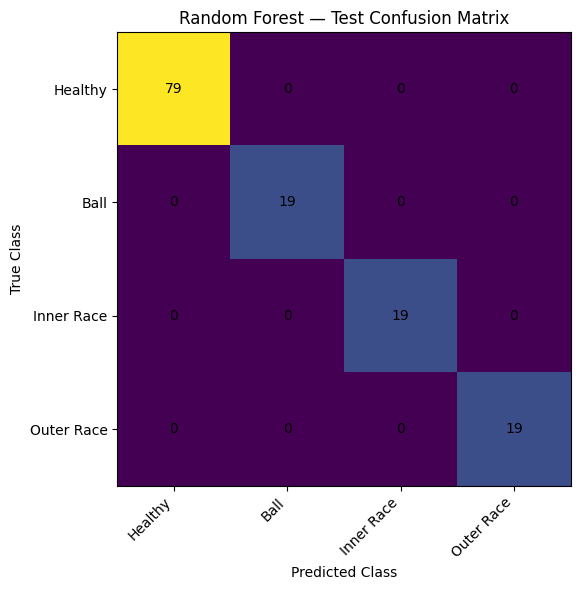

In [109]:
plt.figure(figsize=(7, 6))

plt.imshow(rf_cm)

plt.title(
    "Random Forest — Test Confusion Matrix"
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.xticks(
    range(4),
    CLASS_NAMES,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(4),
    CLASS_NAMES
)

for i in range(4):
    for j in range(4):
        plt.text(
            j,
            i,
            rf_cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [110]:
rf_importance_df = pd.DataFrame({
    "Feature": FEATURE_COLUMNS,
    "Importance": rf_model.feature_importances_
})

rf_importance_df = (
    rf_importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(rf_importance_df)

,Feature,Importance
0,Low_Frequency_Energy,0.096161
1,Variance,0.087385
2,Minimum,0.084105
3,RMS,0.079790
4,Spectral_RMS,0.079520
5,Peak_to_Peak,0.078103
6,Total_Spectral_Energy,0.076085
7,Maximum,0.068465
8,High_Frequency_Energy,0.064948
9,Mid_Frequency_Energy,0.062042


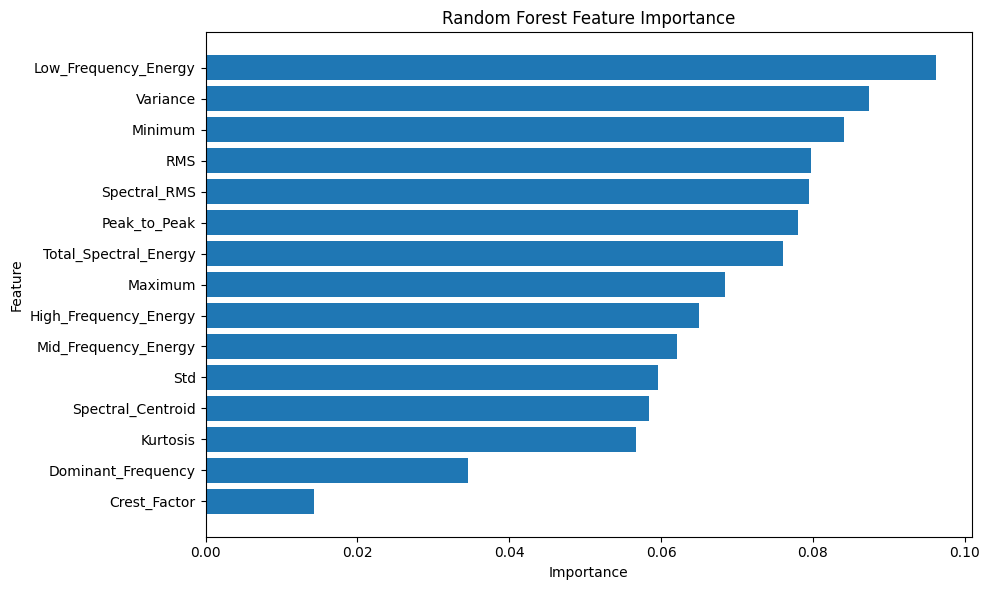

In [111]:
plt.figure(figsize=(10, 6))

plt.barh(
    rf_importance_df["Feature"],
    rf_importance_df["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Random Forest Feature Importance"
)

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [112]:
import joblib

MODEL_DIR = (
    PROJECT_ROOT / "models"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

rf_model_path = (
    MODEL_DIR
    / "random_forest_baseline_corrected.joblib"
)

joblib.dump(
    rf_model,
    rf_model_path
)

print(
    "Random Forest saved:"
)

print(
    rf_model_path
)

Random Forest saved:
C:\Users\armaa\OneDrive\Desktop\TinyML-Vibration-Anomaly-Detection\models\random_forest_baseline_corrected.joblib


In [ ]:
##SVM BASELINE

In [113]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

print("SVM libraries ready.")

SVM libraries ready.


In [115]:
svm_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "svm",
        SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            probability=True,
            random_state=42
        )
    )
])

print("SVM pipeline created.")

SVM pipeline created.


In [116]:
svm_model.fit(
    X_train,
    y_train
)

print(
    "SVM training completed."
)

SVM training completed.


In [117]:
y_val_pred_svm = svm_model.predict(
    X_val
)

svm_val_accuracy = accuracy_score(
    y_val,
    y_val_pred_svm
)

print(
    f"SVM Validation Accuracy: "
    f"{svm_val_accuracy:.4f}"
)

SVM Validation Accuracy: 1.0000


In [118]:
print(
    classification_report(
        y_val,
        y_val_pred_svm,
        labels=[0, 1, 2, 3],
        target_names=CLASS_NAMES,
        zero_division=0
    )
)

              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00       158
        Ball       1.00      1.00      1.00        19
  Inner Race       1.00      1.00      1.00        19
  Outer Race       1.00      1.00      1.00        19

    accuracy                           1.00       215
   macro avg       1.00      1.00      1.00       215
weighted avg       1.00      1.00      1.00       215



In [119]:
y_test_pred_svm = svm_model.predict(
    X_test
)

svm_test_accuracy = accuracy_score(
    y_test,
    y_test_pred_svm
)

print(
    f"SVM Test Accuracy: "
    f"{svm_test_accuracy:.4f}"
)

SVM Test Accuracy: 1.0000


In [120]:
print(
    classification_report(
        y_test,
        y_test_pred_svm,
        labels=[0, 1, 2, 3],
        target_names=CLASS_NAMES,
        zero_division=0
    )
)

              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00        79
        Ball       1.00      1.00      1.00        19
  Inner Race       1.00      1.00      1.00        19
  Outer Race       1.00      1.00      1.00        19

    accuracy                           1.00       136
   macro avg       1.00      1.00      1.00       136
weighted avg       1.00      1.00      1.00       136



In [121]:
from sklearn.linear_model import LogisticRegression
logreg_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "logistic_regression",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        )
    )
])

print(
    "Logistic Regression pipeline created."
)

Logistic Regression pipeline created.


In [122]:
logreg_model.fit(
    X_train,
    y_train
)

print(
    "Logistic Regression training completed."
)

Logistic Regression training completed.


In [123]:
y_val_pred_logreg = logreg_model.predict(
    X_val
)

logreg_val_accuracy = accuracy_score(
    y_val,
    y_val_pred_logreg
)

print(
    f"Logistic Regression Validation Accuracy: "
    f"{logreg_val_accuracy:.4f}"
)


Logistic Regression Validation Accuracy: 1.0000


In [124]:
y_test_pred_logreg = logreg_model.predict(
    X_test
)

logreg_test_accuracy = accuracy_score(
    y_test,
    y_test_pred_logreg
)

print(
    f"Logistic Regression Test Accuracy: "
    f"{logreg_test_accuracy:.4f}"
)

print(
    classification_report(
        y_test,
        y_test_pred_logreg,
        labels=[0, 1, 2, 3],
        target_names=CLASS_NAMES,
        zero_division=0
    )
)

Logistic Regression Test Accuracy: 1.0000
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00        79
        Ball       1.00      1.00      1.00        19
  Inner Race       1.00      1.00      1.00        19
  Outer Race       1.00      1.00      1.00        19

    accuracy                           1.00       136
   macro avg       1.00      1.00      1.00       136
weighted avg       1.00      1.00      1.00       136



In [125]:
baseline_comparison = pd.DataFrame([
    {
        "Model": "Random Forest",
        "Validation Accuracy": rf_val_accuracy,
        "Test Accuracy": rf_test_accuracy,
        "Test Precision": precision_score(
            y_test,
            y_test_pred_rf,
            average="weighted",
            zero_division=0
        ),
        "Test Recall": recall_score(
            y_test,
            y_test_pred_rf,
            average="weighted",
            zero_division=0
        ),
        "Test F1": f1_score(
            y_test,
            y_test_pred_rf,
            average="weighted",
            zero_division=0
        )
    },
    {
        "Model": "SVM",
        "Validation Accuracy": svm_val_accuracy,
        "Test Accuracy": svm_test_accuracy,
        "Test Precision": precision_score(
            y_test,
            y_test_pred_svm,
            average="weighted",
            zero_division=0
        ),
        "Test Recall": recall_score(
            y_test,
            y_test_pred_svm,
            average="weighted",
            zero_division=0
        ),
        "Test F1": f1_score(
            y_test,
            y_test_pred_svm,
            average="weighted",
            zero_division=0
        )
    },
    {
        "Model": "Logistic Regression",
        "Validation Accuracy": logreg_val_accuracy,
        "Test Accuracy": logreg_test_accuracy,
        "Test Precision": precision_score(
            y_test,
            y_test_pred_logreg,
            average="weighted",
            zero_division=0
        ),
        "Test Recall": recall_score(
            y_test,
            y_test_pred_logreg,
            average="weighted",
            zero_division=0
        ),
        "Test F1": f1_score(
            y_test,
            y_test_pred_logreg,
            average="weighted",
            zero_division=0
        )
    }
])

baseline_comparison = baseline_comparison.round(4)

display(
    baseline_comparison
)

,Model,Validation Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1
0,Random Forest,1.0,1.0,1.0,1.0,1.0
1,SVM,1.0,1.0,1.0,1.0,1.0
2,Logistic Regression,1.0,1.0,1.0,1.0,1.0


In [126]:
def plot_cm(cm, title):

    plt.figure(figsize=(7, 6))

    plt.imshow(cm)

    plt.title(title)

    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")

    plt.xticks(
        range(4),
        CLASS_NAMES,
        rotation=45,
        ha="right"
    )

    plt.yticks(
        range(4),
        CLASS_NAMES
    )

    for i in range(4):
        for j in range(4):
            plt.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )

    plt.tight_layout()
    plt.show()

#RF

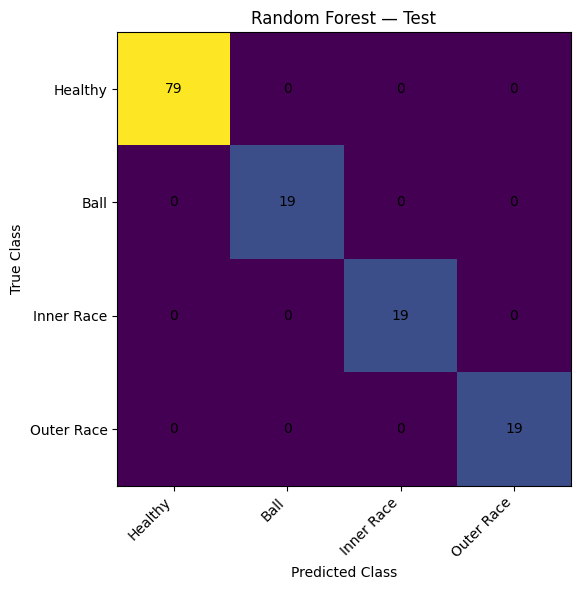

In [127]:
plot_cm(
    confusion_matrix(
        y_test,
        y_test_pred_rf,
        labels=[0, 1, 2, 3]
    ),
    "Random Forest — Test"
)

#SVM

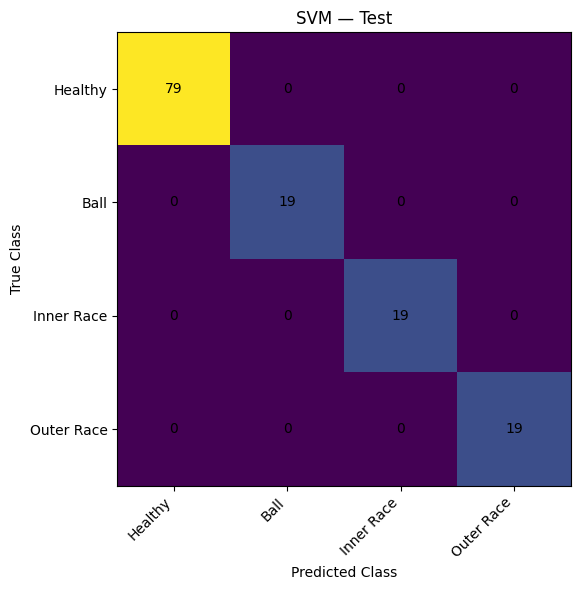

In [128]:
plot_cm(
    confusion_matrix(
        y_test,
        y_test_pred_svm,
        labels=[0, 1, 2, 3]
    ),
    "SVM — Test"
)

#LOGISTIC REGRESSION

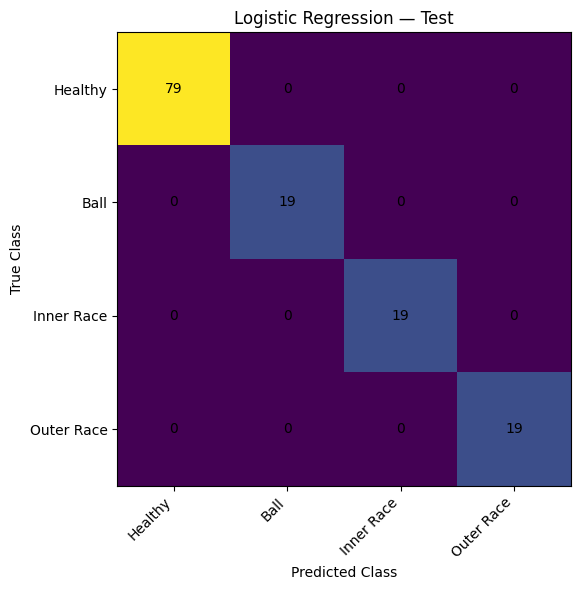

In [129]:
plot_cm(
    confusion_matrix(
        y_test,
        y_test_pred_logreg,
        labels=[0, 1, 2, 3]
    ),
    "Logistic Regression — Test"
)

In [130]:
RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "baseline_corrected"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

baseline_comparison.to_csv(
    RESULTS_DIR
    / "baseline_model_comparison.csv",
    index=False
)

rf_importance_df.to_csv(
    RESULTS_DIR
    / "random_forest_feature_importance.csv",
    index=False
)

print(
    "Baseline results saved to:"
)

print(
    RESULTS_DIR
)

Baseline results saved to:
C:\Users\armaa\OneDrive\Desktop\TinyML-Vibration-Anomaly-Detection\results\baseline_corrected


In [131]:
joblib.dump(
    svm_model,
    MODEL_DIR
    / "svm_baseline_corrected.joblib"
)

joblib.dump(
    logreg_model,
    MODEL_DIR
    / "logistic_regression_baseline_corrected.joblib"
)

print(
    "All baseline models saved."
)

All baseline models saved.


In [132]:
np.savetxt(
    RESULTS_DIR
    / "random_forest_confusion_matrix.csv",
    confusion_matrix(
        y_test,
        y_test_pred_rf,
        labels=[0, 1, 2, 3]
    ),
    delimiter=",",
    fmt="%d"
)

np.savetxt(
    RESULTS_DIR
    / "svm_confusion_matrix.csv",
    confusion_matrix(
        y_test,
        y_test_pred_svm,
        labels=[0, 1, 2, 3]
    ),
    delimiter=",",
    fmt="%d"
)

np.savetxt(
    RESULTS_DIR
    / "logistic_regression_confusion_matrix.csv",
    confusion_matrix(
        y_test,
        y_test_pred_logreg,
        labels=[0, 1, 2, 3]
    ),
    delimiter=",",
    fmt="%d"
)

print("Confusion matrices saved.")

Confusion matrices saved.
